# Power Analysis


In [96]:
import numpy as np
import pingouin as pg
import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# statsmodels for power calculations
from statsmodels.stats.power import FTestAnovaPower
from statsmodels.stats.multicomp import pairwise_tukeyhsd

np.random.seed(42)
print('Libraries loaded successfully.')

Libraries loaded successfully.


## 1. Study Parameters

In [97]:
# ── Standard parameters ──────────────────────────────────────────────────────
ALPHA        = 0.05          # significance level
TARGET_POWER = 0.80          # conventional minimum power
# Cohen's f values: small 0.10, medium 0.25, large 0.40
# for a small-ish effect size, we would need a lot of participants per group 
EFFECT_SIZE = 0.40
N_GROUPS     = 3             # number of conditions

# For discussion: running more participants could boost our power analysis, assuming still no differences
N_PER_GROUP  = 50            # number of participants per condition   

## 2. Prospective Power Analysis — Minimum Required Sample Size

How many participants per group are needed to detect an effect with 80% power?

In [98]:
power_analysis = FTestAnovaPower()

n_required = power_analysis.solve_power(
    effect_size=EFFECT_SIZE,
    alpha=ALPHA,
    power=TARGET_POWER,
    k_groups=N_GROUPS
)

n_required_ceil = int(np.ceil(n_required))

print('─' * 50)
print(f'Minimum n per group : {n_required_ceil}')
print(f'Total N required    : {n_required_ceil * N_GROUPS}')
print('─' * 50)

──────────────────────────────────────────────────
Minimum n per group : 64
Total N required    : 192
──────────────────────────────────────────────────


## 3. Power Curve — Across a Range of Sample Sizes (for investigating f-value)

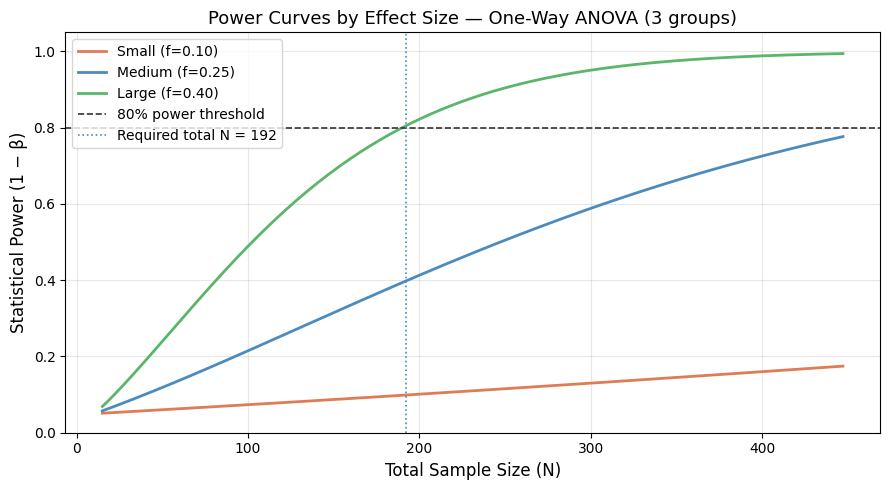

In [99]:
ns = np.arange(5, 150, 1)

power_values = [
    power_analysis.solve_power(
        effect_size=EFFECT_SIZE,
        alpha=ALPHA,
        nobs=n,
        k_groups=N_GROUPS
    )
    for n in ns
]

# ── Power curves for small / medium / large effects ───────────────────────────
effect_sizes = {'Small (f=0.10)': 0.10, 'Medium (f=0.25)': 0.25, 'Large (f=0.40)': 0.40}
power_curves = {
    label: [
        power_analysis.solve_power(effect_size=f, alpha=ALPHA, nobs=n, k_groups=N_GROUPS)
        for n in ns
    ]
    for label, f in effect_sizes.items()
}

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#e07b54', '#4c8bbe', '#5bb56b']

for (label, pv), color in zip(power_curves.items(), colors):
    ax.plot(ns * N_GROUPS, pv, label=label, color=color, lw=2)

ax.axhline(TARGET_POWER, ls='--', color='#333', lw=1.2, label='80% power threshold')
ax.axvline(n_required_ceil * N_GROUPS, ls=':', color='#4c8bbe', lw=1.2,
           label=f'Required total N = {n_required_ceil * N_GROUPS}')

ax.set_xlabel('Total Sample Size (N)', fontsize=12)
ax.set_ylabel('Statistical Power (1 − β)', fontsize=12)
ax.set_title('Power Curves by Effect Size — One-Way ANOVA (3 groups)', fontsize=13)
ax.legend(fontsize=10)
ax.set_ylim(0, 1.05)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Read in Memory Test data / get MEANS / get SDs


In [100]:
import pandas as pd

INDIVIDUAL_MEMORY_TEST_DATA = pd.read_csv('./data/for-analysis/test_data.csv')

In [101]:
ANALYSIS_DATA = INDIVIDUAL_MEMORY_TEST_DATA[['pid','condition', 'breakpoint', 'euclidean']]


In [102]:
ANALYSIS_DATA['condition'].unique()

<StringArray>
['Shipwrecked', 'Baseline', 'Safecracker']
Length: 3, dtype: str

In [103]:
CONDITION_MEANS = [
    ANALYSIS_DATA[ANALYSIS_DATA['condition'] == 'Shipwrecked']['euclidean'].mean(),
    ANALYSIS_DATA[ANALYSIS_DATA['condition'] == 'Safecracjer']['euclidean'].mean(),
    ANALYSIS_DATA[ANALYSIS_DATA['condition'] == 'Baseline']['euclidean'].mean()
]
CONDITION_SDS   = [
    ANALYSIS_DATA[ANALYSIS_DATA['condition'] == 'Shipwrecked']['euclidean'].std(),
    ANALYSIS_DATA[ANALYSIS_DATA['condition'] == 'Safecracjer']['euclidean'].std(),
    ANALYSIS_DATA[ANALYSIS_DATA['condition'] == 'Baseline']['euclidean'].std()
]

In [104]:
SHIPWRECKED = ANALYSIS_DATA[ANALYSIS_DATA['condition'] == 'Shipwrecked']
SAFECRACKER = ANALYSIS_DATA[ANALYSIS_DATA['condition'] == 'Safecracker']
BASELINE = ANALYSIS_DATA[ANALYSIS_DATA['condition'] == 'Baseline']

euclideans = ANALYSIS_DATA['euclidean']

## 5. Read in all ANOVA tables from Morgan's analysis

In [105]:
SEQUENCE_TEST_CONFIDENCE = './data/anova-results-50-participants/sequence_test_confidence.csv'
SEQUENCE_TEST_EUCLIDEAN = './data/anova-results-50-participants/sequence-test-anova-euclidean.csv'
SEQUENCE_TEST_EUCLIDEAN_BLOCK1 = './data/anova-results-50-participants/sequence-test-anova-euclidean-block1.csv'
SEQUENCE_TEST_EUCLIDEAN_BLOCK2_4 = './data/anova-results-50-participants/sequence-test-anova-euclidean-block2-4.csv'
TEST_ANOVA_EUCLIDEAN = './data/anova-results-50-participants/test-anova-euclidean.csv'
TEST_ANOVA_EUCLIDEAN_BLOCK1 = './data/anova-results-50-participants/test-anova-euclidean-block1.csv'
TEST_ANOVA_EUCLIDEAN_BLOCK2_4 = './data/anova-results-50-participants/test-anova-euclidean-block2-4.csv'
TEST_CONFIDENCE = './data/anova-results-50-participants/test-confidence-anova.csv'
TRAINING_ANOVA = './data/anova-results-50-participants/training-anova.csv'
TRAINING_ERRORS_ANOVA = './data/anova-results-50-participants/training-errors-anova.csv'



In [106]:
def retrospective_power_analysis_confidence(anova_table, filename):


    # np2 = Sum Sq / (Sum Sq + Sum Sq.res)
    anova_table['np2'] = anova_table['Sum Sq'] / (anova_table['Sum Sq'] + anova_table['Sum Sq.res'])

    # Compute Cohen's f from np2
    anova_table['cohens_f'] = np.sqrt(anova_table['np2'] / (1 - anova_table['np2']))

    # ── Retrospective power ───────────────────────────────────────────────────────
    with open(filename, 'w') as output:
        print('─' * 65, file=output)
        print(f"{'Effect':<25} {'Error':<12} {'Cohen\'s f':<12} {'Power':<10} {'Adequately powered?'}", file=output)
        print('─' * 65, file=output)

        for _, row in anova_table.iterrows():
            source = row['Term']
            error = row['Error']
            f      = max(row['cohens_f'], 0.001)
            p      = row['Pr(>F)']

            # Between-subjects effect
            if row['Error'] == 'Within':
                power = power_analysis.solve_power(
                    effect_size=f,
                    alpha=ALPHA,
                    nobs=N_PER_GROUP,
                    k_groups=N_GROUPS
                )
            # Within-subjects and interaction effects
            else:
                power = power_analysis.solve_power(
                    effect_size=f,
                    alpha=ALPHA,
                    nobs=N_PER_GROUP,
                    k_groups=int(row['Df']) + 1
                )

            adequate = '✔ Yes' if power >= TARGET_POWER else '✘ No'
            print(f'{source:<25} {error:<12} {f:<12.3f} {power:<10.3f} {adequate}', file=output)

        print('─' * 65, file=output)
    output.close()
    print("Results saved to " + filename + "\n")

In [107]:
ANOVA_TABLE = pd.read_csv(SEQUENCE_TEST_EUCLIDEAN)
ANOVA_TABLE.columns

Index(['Unnamed: 0', 'ANOVA.Effect', 'ANOVA.DFn', 'ANOVA.DFd', 'ANOVA.SSn',
       'ANOVA.SSd', 'ANOVA.F', 'ANOVA.p', 'ANOVA.p..05', 'ANOVA.ges'],
      dtype='str')

In [108]:
def retrospective_power_analysis(anova_table, filename):

    # Compute Cohen's f directly from ges
    anova_table['cohens_f'] = np.sqrt(anova_table['ANOVA.ges'] / (1 - anova_table['ANOVA.ges']))

    # ── Retrospective power ───────────────────────────────────────────────────────
    with open(filename, 'w') as output:
        print('─' * 65, file=output)
        print(f"{'Effect':<25} {'Cohen\'s f':<12} {'Power':<10} {'Adequately powered?'}", file=output)
        print('─' * 65, file=output)

        for _, row in anova_table.iterrows():
            source = row['ANOVA.Effect']
            f      = max(row['cohens_f'], 0.001)
            p      = row['ANOVA.p']

            # Between-subjects effect
            if row['ANOVA.Effect'] == 'condition':
                power = power_analysis.solve_power(
                    effect_size=f,
                    alpha=ALPHA,
                    nobs=N_PER_GROUP,
                    k_groups=N_GROUPS
                )
            # Within-subjects and interaction effects
            else:
                power = power_analysis.solve_power(
                    effect_size=f,
                    alpha=ALPHA,
                    nobs=N_PER_GROUP,
                    k_groups=int(row['ANOVA.DFn']) + 1
                )

            adequate = '✔ Yes' if power >= TARGET_POWER else '✘ No'
            print(f'{source:<25} {f:<12.3f} {power:<10.3f} {adequate}', file=output)

        print('─' * 65, file=output)

    print("Results saved to " + filename + "\n")

<!-- ## 5. Mixed ANOVA with Pingouin Library

This would work if I cleaned the data to remove participants who missed a trial or were removed from a trial. 

TODO: Read in Morgan's tables and use the function to get the 'real' Cohen's value.  -->

In [109]:
retrospective_power_analysis_confidence(pd.read_csv(TEST_CONFIDENCE), './power-analysis/test_confidence_power_analysis.txt')
retrospective_power_analysis_confidence(pd.read_csv(SEQUENCE_TEST_CONFIDENCE), './power-analysis/sequence_test_confidence_power_analysis.txt')


Results saved to ./power-analysis/test_confidence_power_analysis.txt

Results saved to ./power-analysis/sequence_test_confidence_power_analysis.txt



<!-- ## 5. One-Way ANOVA -->

In [110]:
retrospective_power_analysis(pd.read_csv(SEQUENCE_TEST_EUCLIDEAN), './power-analysis/sequence_test_euclidean_power_analysis.txt')
retrospective_power_analysis(pd.read_csv(SEQUENCE_TEST_EUCLIDEAN_BLOCK1), './power-analysis/sequence_test_euclidean_block1_power_analysis.txt')
retrospective_power_analysis(pd.read_csv(SEQUENCE_TEST_EUCLIDEAN_BLOCK2_4), './power-analysis/sequence_test_euclidean_block2_4_power_analysis.txt')
retrospective_power_analysis(pd.read_csv(TEST_ANOVA_EUCLIDEAN), './power-analysis/test_anova_euclidean_power_analysis.txt')
retrospective_power_analysis(pd.read_csv(TEST_ANOVA_EUCLIDEAN_BLOCK1), './power-analysis/test_anova_euclidean_block1_power_analysis.txt')
retrospective_power_analysis(pd.read_csv(TEST_ANOVA_EUCLIDEAN_BLOCK2_4), './power-analysis/test_anova_euclidean_block2_4_power_analysis.txt')   
retrospective_power_analysis(pd.read_csv(TRAINING_ANOVA), './power-analysis/training_anova_power_analysis.txt')
retrospective_power_analysis(pd.read_csv(TRAINING_ERRORS_ANOVA), './power-analysis/training_errors_anova_power_analysis.txt')

Results saved to ./power-analysis/sequence_test_euclidean_power_analysis.txt

Results saved to ./power-analysis/sequence_test_euclidean_block1_power_analysis.txt

Results saved to ./power-analysis/sequence_test_euclidean_block2_4_power_analysis.txt

Results saved to ./power-analysis/test_anova_euclidean_power_analysis.txt

Results saved to ./power-analysis/test_anova_euclidean_block1_power_analysis.txt

Results saved to ./power-analysis/test_anova_euclidean_block2_4_power_analysis.txt

Results saved to ./power-analysis/training_anova_power_analysis.txt

Results saved to ./power-analysis/training_errors_anova_power_analysis.txt



## 7. Sensitivity Analysis — Smallest Detectable Effect

In [111]:
mde = power_analysis.solve_power(
    alpha=ALPHA,
    power=TARGET_POWER,
    nobs=N_PER_GROUP,
    k_groups=N_GROUPS
)

print(f'With n={N_PER_GROUP} per group, we can detect effects as small as:')
print(f"  Cohen's f ≥ {mde:.3f}")
print(f'  (at α={ALPHA}, power={TARGET_POWER})')


With n=50 per group, we can detect effects as small as:
  Cohen's f ≥ 0.453
  (at α=0.05, power=0.8)


## 8. TOST

**Two One-Sided Tests (TOST)**: directly test whether the effect is *smaller than a meaningful threshold*, providing positive evidence for the null.

In [112]:
# Pairwise TOST for each pair of conditions
# Equivalence bounds: ±0.5 SD (half a standard deviation = small practical threshold)
EQUIV_BOUND_SD = 0.5
pooled_sd = np.sqrt(np.mean([np.var(g, ddof=1) for g in [SHIPWRECKED['euclidean'], SAFECRACKER['euclidean'], BASELINE['euclidean']]]))
equiv_bound = EQUIV_BOUND_SD * pooled_sd

print(f'Equivalence bound: ±{equiv_bound:.2f} ({EQUIV_BOUND_SD} SD = {EQUIV_BOUND_SD} × {pooled_sd:.2f})')
print()

pairs = [('A', 'B', SHIPWRECKED['euclidean'], SAFECRACKER['euclidean']), ('A', 'C', SHIPWRECKED['euclidean'], BASELINE['euclidean']), ('B', 'C', SAFECRACKER['euclidean'], BASELINE['euclidean'])]

for lbl1, lbl2, g1, g2 in pairs:
    diff = g1.mean() - g2.mean()
    se   = np.sqrt(g1.var(ddof=1)/len(g1) + g2.var(ddof=1)/len(g2))
    df   = len(g1) + len(g2) - 2

    # TOST: two one-sided t-tests
    t_low  = (diff - (-equiv_bound)) / se   # upper bound test
    t_high = (diff -   equiv_bound)  / se   # lower bound test
    p_low  = stats.t.cdf(t_low,  df)
    p_high = 1 - stats.t.cdf(t_high, df)
    p_tost = max(p_low, p_high)             # TOST p = max of the two

    equiv = '✔ Equivalent' if p_tost < ALPHA else '— Not established'
    print(f'  {lbl1} vs {lbl2}: Δ={diff:+.3f}  TOST p={p_tost:.4f}  → {equiv}')

Equivalence bound: ±50.85 (0.5 SD = 0.5 × 101.70)

  A vs B: Δ=-2.742  TOST p=1.0000  → — Not established
  A vs C: Δ=+6.832  TOST p=1.0000  → — Not established
  B vs C: Δ=+9.574  TOST p=1.0000  → — Not established
